# Uses 'aug10_data.csv'

In [ ]:
# NW  N  NE
# W   x  E
# SW  S  SE

In [1]:
import random

data = [[0] * 16 for _ in range(16)]
for i in range(len(data)):
    for j in range(len(data)):
        data[i][j] = '' #4*i + j + 1

default_x = 6
default_y = 6
data[default_x][default_y] = "O"

for row in data:
    print(row)

['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', 'O', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['', '', '', '', '', '',

In [7]:
import random
import csv

direction_list = ["north", "south", "east", "west", "northwest", "southwest", "northeast", "southeast"]
healthstatus_list = [75, 80, 85, 90, 95, 100]
time_list = [5, 6, 7, 8, 9]
header = ['ID', 'Direction', 'Time', 'HealthStatus']
final = []

for i in range(200):
    inp = random.choice(direction_list)
    health = random.choice(healthstatus_list)
    time = random.choice(time_list)
    #print(inp)

    if inp == "north":
        if(default_x - 1 > -1):
            default_x -= 1

        data[default_x][default_y] = "O"

    if inp == "south":
        if(default_x + 1 < 16):
            default_x += 1

        data[default_x][default_y] = "O"

    if inp == "east":
        if(default_y + 1 < 16):
            default_y += 1

        data[default_x][default_y] = "O"

    if inp == "west":
        if(default_y - 1 > -1):
            default_y -= 1

        data[default_x][default_y] = "O"

    if inp == "northwest":
        if(default_x - 1 > -1 and default_y > -1):
            default_x -= 1
            default_y -= 1

        data[default_x][default_y] = "O"

    if inp == "northeast":
        if(default_x - 1 > -1 and default_y + 1 < 16):
            default_x -= 1
            default_y += 1

        data[default_x][default_y] = "O"

    if inp == "southeast":
        if(default_x + 1 < 16 and default_y + 1 < 16):
            default_x += 1
            default_y += 1

        data[default_x][default_y] = "O"

    if inp == "southwest":
        if(default_x + 1 < 16 and default_y - 1 > -1):
            default_x += 1
            default_y -= 1

        data[default_x][default_y] = "O"
    
    final.append([default_x*16 + default_y + 1, inp, time, health])
    
with open('aug10_data.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final)     
    
#for row in data:
#    print(row)

In [9]:
import pandas as pd

# north - 0, south - 1, east - 2, west - 3, northwest - 4, southwest - 5, northeast - 6, southeast - 7

new_data = pd.read_csv("aug10_data.csv")
new_data2 = new_data.replace("north", 0).replace("south", 1).replace("east", 2).replace("west", 3) \
            .replace("northwest", 4).replace("southwest", 5).replace("northeast", 6).replace("southeast", 7)
new_data2

,ID,Direction,Time,HealthStatus
0,119,1,8,80
1,118,3,8,80
2,119,2,7,100
3,136,7,9,95
4,135,3,9,90
...,...,...,...,...
195,73,1,9,85
196,90,7,9,75
197,73,4,6,90
198,90,7,6,95


Enter a starting number: 0
Enter an ending number: 100


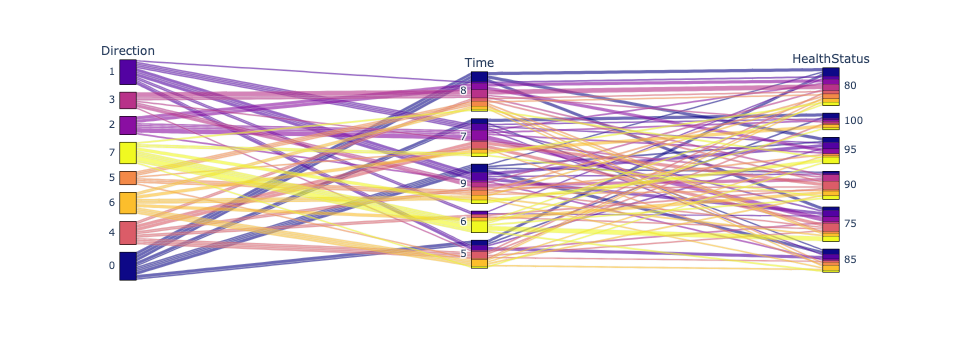

In [24]:
import pandas as pd
import numpy as np
import plotly.express as px

start = int(input("Enter a starting number:"))
end = int(input("Enter an ending number:"))
new_data3 = new_data2.iloc[start:end+1, :]

fig = px.parallel_categories(new_data3, color = "Direction") #color_continuous_scale=["red", "green", "blue"]
fig.update_coloraxes(showscale=False)
fig.show()

# north - 0, south - 1, east - 2, west - 3, northwest - 4, southwest - 5, northeast - 6, southeast - 7